In [70]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df = pd.read_csv('train.csv')

In [72]:
df.shape

(891, 12)

In [73]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [74]:
df.columns.values

array(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype=object)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [76]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [77]:
df.drop(columns=['Cabin'],inplace=True)

In [78]:
df['Age'].head(10)

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: Age, dtype: float64

In [79]:
df['Age'].isnull().sum()

np.int64(177)

In [80]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [81]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [82]:
df['Embarked'].value_counts()
df['Embarked'] = df['Embarked'].fillna('S')

In [83]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [84]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [85]:
df['Survived']=df['Survived'].astype('category')
df['Pclass']=df['Pclass'].astype('category')
df['Sex']=df['Sex'].astype('category')
df['Age']=df['Age'].astype('category')
df['Embarked']=df['Embarked'].astype('category')

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    category
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(5), float64(1), int64(3), object(2)
memory usage: 49.5+ KB


In [87]:
df.describe()

,PassengerId,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.523008,0.381594,32.204208
std,257.353842,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,0.000000,31.000000
max,891.000000,8.000000,6.000000,512.329200


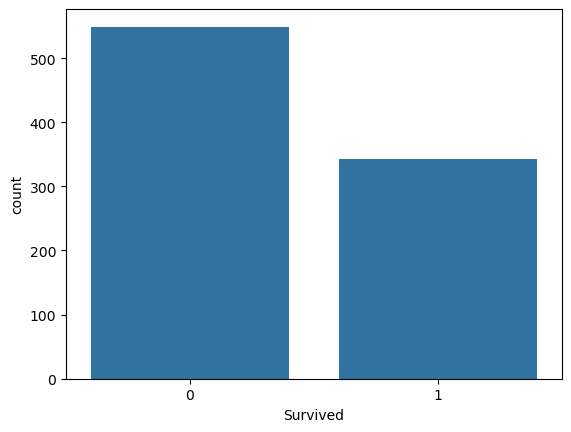

In [88]:
sns.countplot(x=df['Survived'])
plt.show()

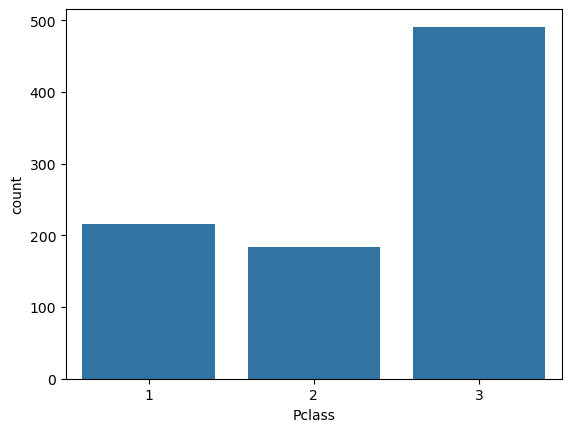

In [89]:
sns.countplot(x=df['Pclass'])
plt.show()

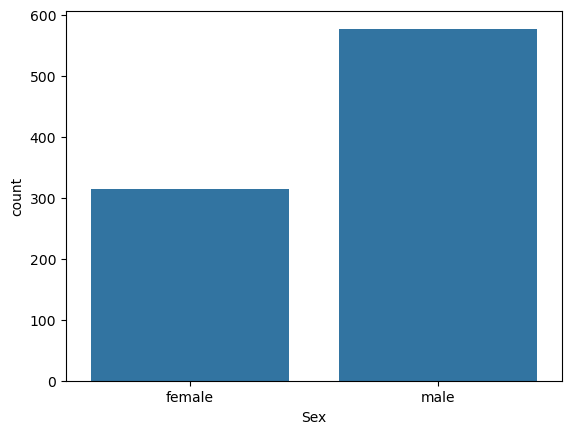

In [90]:
sns.countplot(x=df['Sex'])
plt.show()

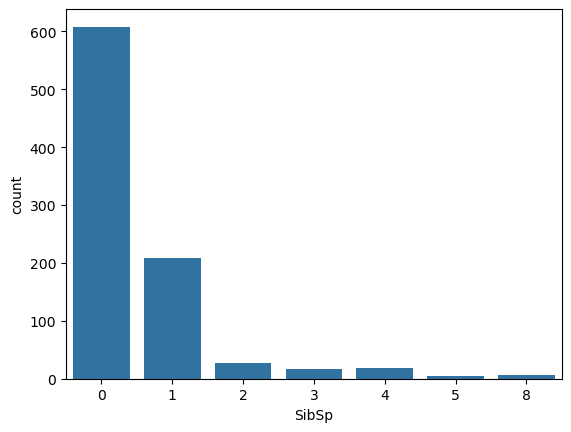

In [91]:
sns.countplot(x=df['SibSp'])
plt.show()

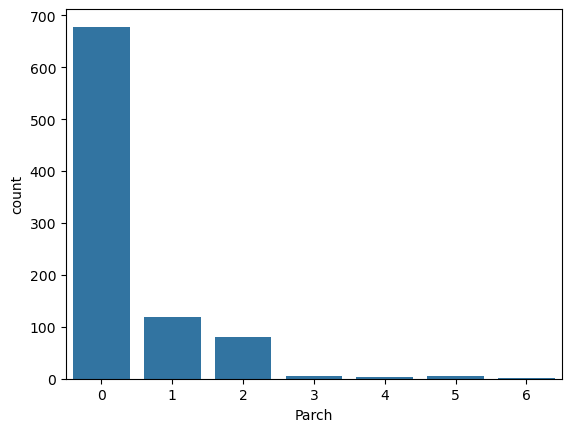

In [92]:
sns.countplot(x=df['Parch'])
plt.show()

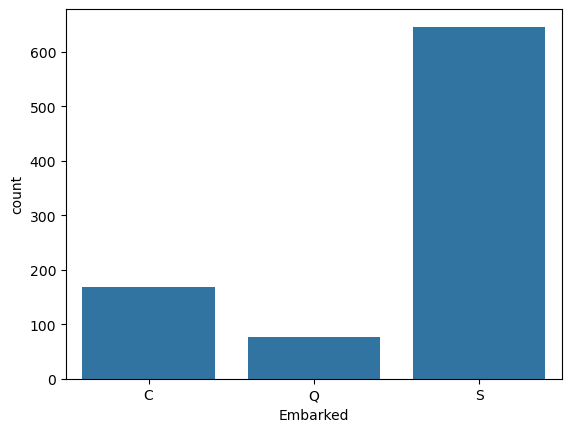

In [93]:
sns.countplot(x=df['Embarked'])
plt.show()

In [94]:
df['Age'] = df['Age'].astype(float)

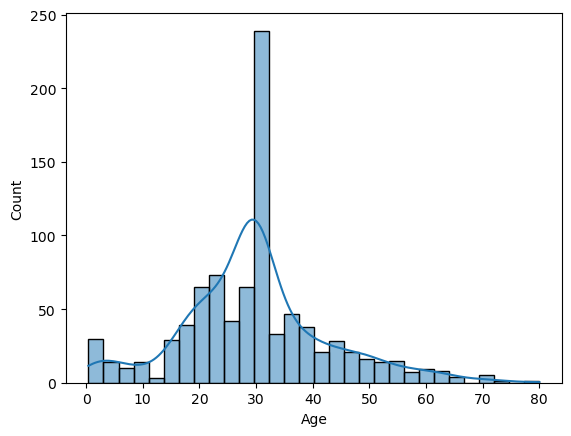

0.4344880940129925
0.9662793026645233


In [95]:
sns.histplot(df['Age'], kde=True)
plt.show()

print(df['Age'].skew())
print(df['Age'].kurt())

<Axes: xlabel='Age'>

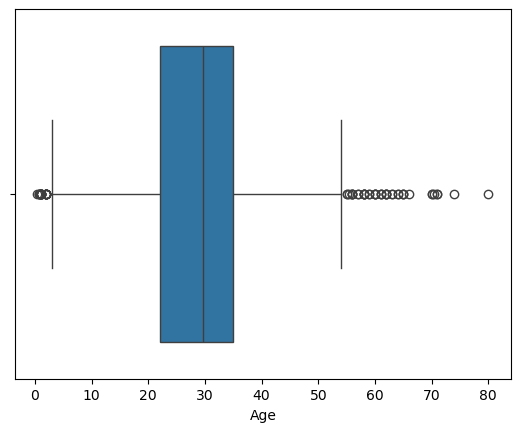

In [96]:
sns.boxplot(x=df['Age'])

In [97]:
print("People with age in between 60 and 70 are",df[(df['Age'] > 60) & (df['Age'] < 70)].shape[0])
print("People with age between 70 and 75 are",df[(df['Age'] >= 70) & (df['Age'] <= 75)].shape[0])
print("People with age greater than 75 are",df[df['Age'] > 75].shape[0])

print('-'*50)

print("People with age between 0 and 1 are",df[df['Age'] < 1].shape[0])

People with age in between 60 and 70 are 15
People with age between 70 and 75 are 6
People with age greater than 75 are 1
--------------------------------------------------
People with age between 0 and 1 are 7


<Axes: xlabel='Fare', ylabel='Count'>

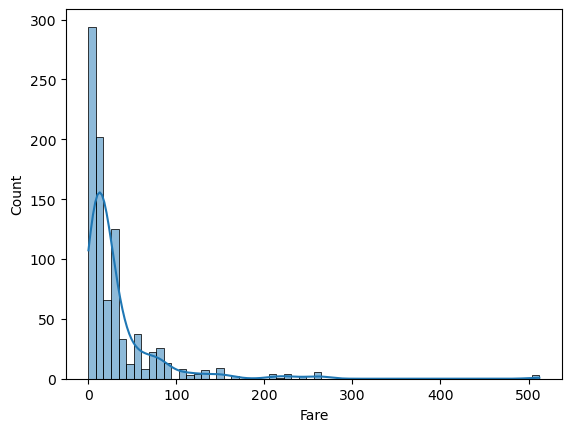

In [98]:
sns.histplot(df['Fare'], kde=True)

In [99]:
print(df['Fare'].skew())

4.787316519674893


In [100]:
print(df['Fare'].kurt())

33.39814088089868


<Axes: xlabel='Fare'>

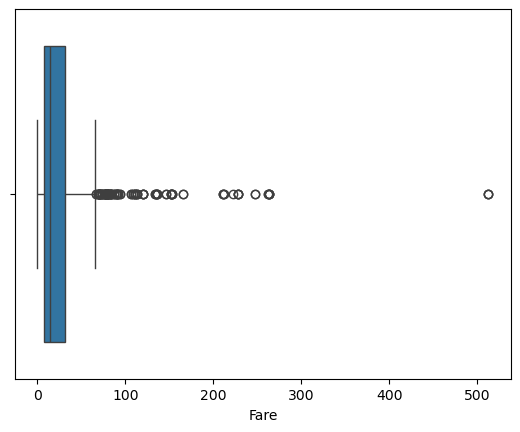

In [101]:
sns.boxplot(x=df['Fare'])

In [102]:
print("People with fare between $200 and $300 are",df[(df['Fare'] > 200) & (df['Fare'] < 300)].shape[0])

print("People with fare greater than $300 are",df[df['Fare'] > 300].shape[0])

People with fare between $200 and $300 are 17
People with fare greater than $300 are 3


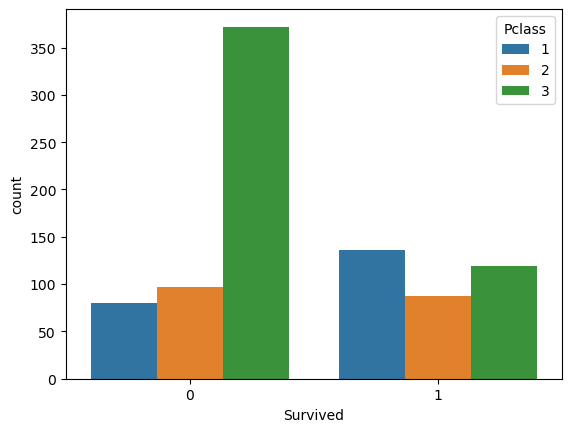

Survived,0,1
Pclass,,
1,37.0,63.0
2,52.7,47.3
3,75.8,24.2


In [103]:
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.show()
pd.crosstab(df['Pclass'], df['Survived']).apply(
    lambda r: round((r / r.sum()) * 100, 1),
    axis=1
)

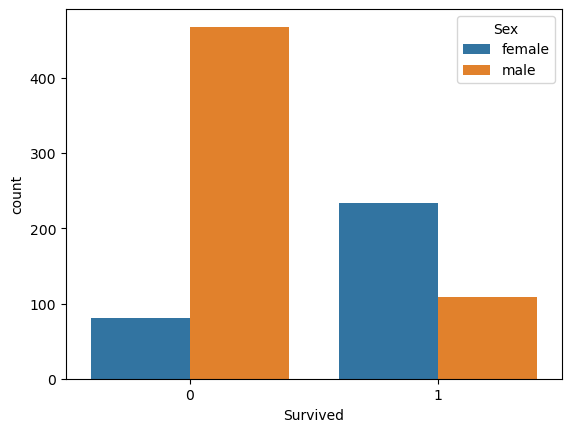

Survived,0,1
Sex,,
female,25.8,74.2
male,81.1,18.9


In [104]:
sns.countplot(data=df, x='Survived', hue='Sex')
plt.show()
pd.crosstab(df['Sex'], df['Survived']).apply(
    lambda r: round((r / r.sum()) * 100, 1),
    axis=1
)

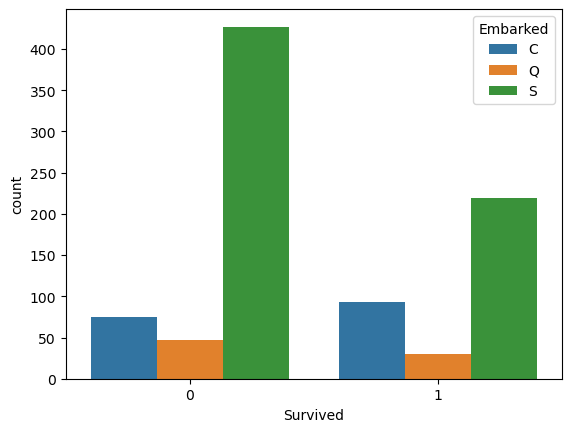

Survived,0,1
Embarked,,
C,44.6,55.4
Q,61.0,39.0
S,66.1,33.9


In [105]:
sns.countplot(data=df, x='Survived', hue='Embarked')
plt.show()
pd.crosstab(df['Embarked'], df['Survived']).apply(
    lambda r: round((r / r.sum()) * 100, 1),
    axis=1
)

<Axes: xlabel='Age', ylabel='Count'>

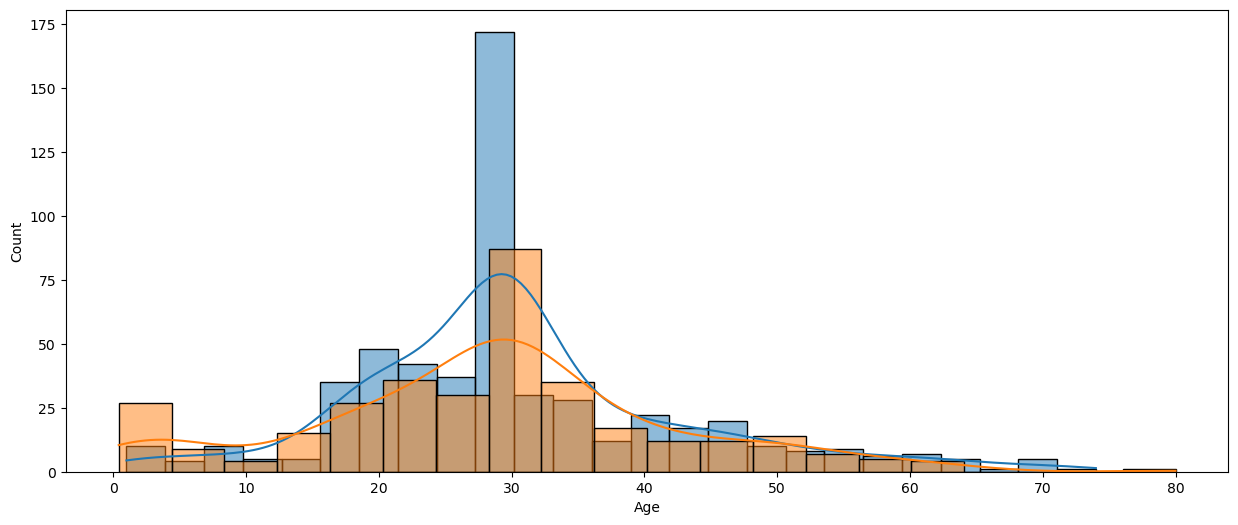

In [106]:
plt.figure(figsize=(15,6))
sns.histplot(df [df['Survived']==0]['Age'], kde=True)
sns.histplot(df [df['Survived']==1]['Age'], kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

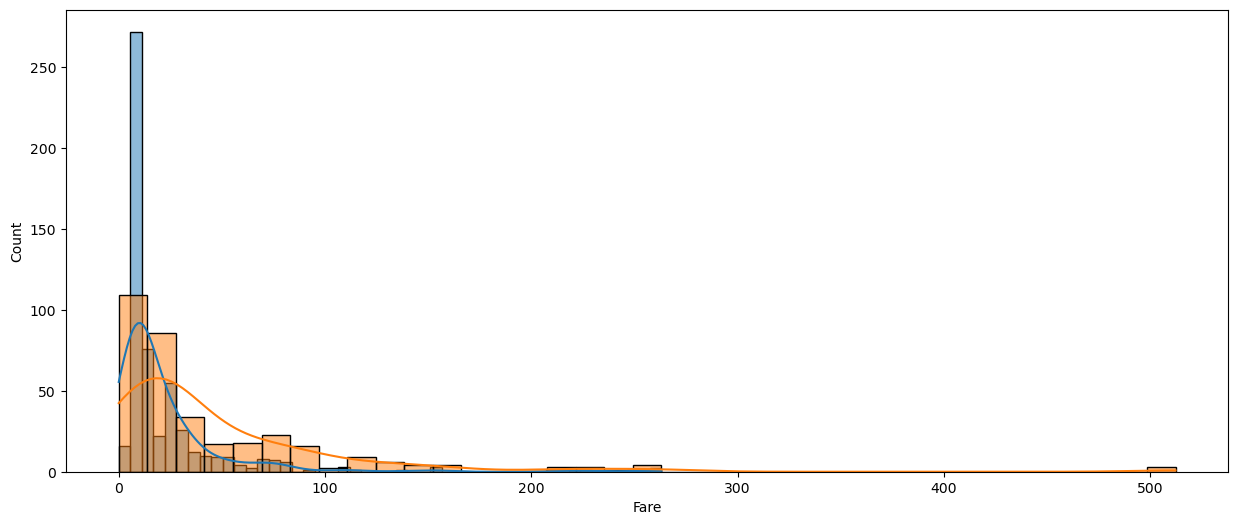

In [107]:
plt.figure(figsize=(15,6))
sns.histplot(df [df['Survived']==0]['Fare'], kde=True)
sns.histplot(df [df['Survived']==1]['Fare'], kde=True)

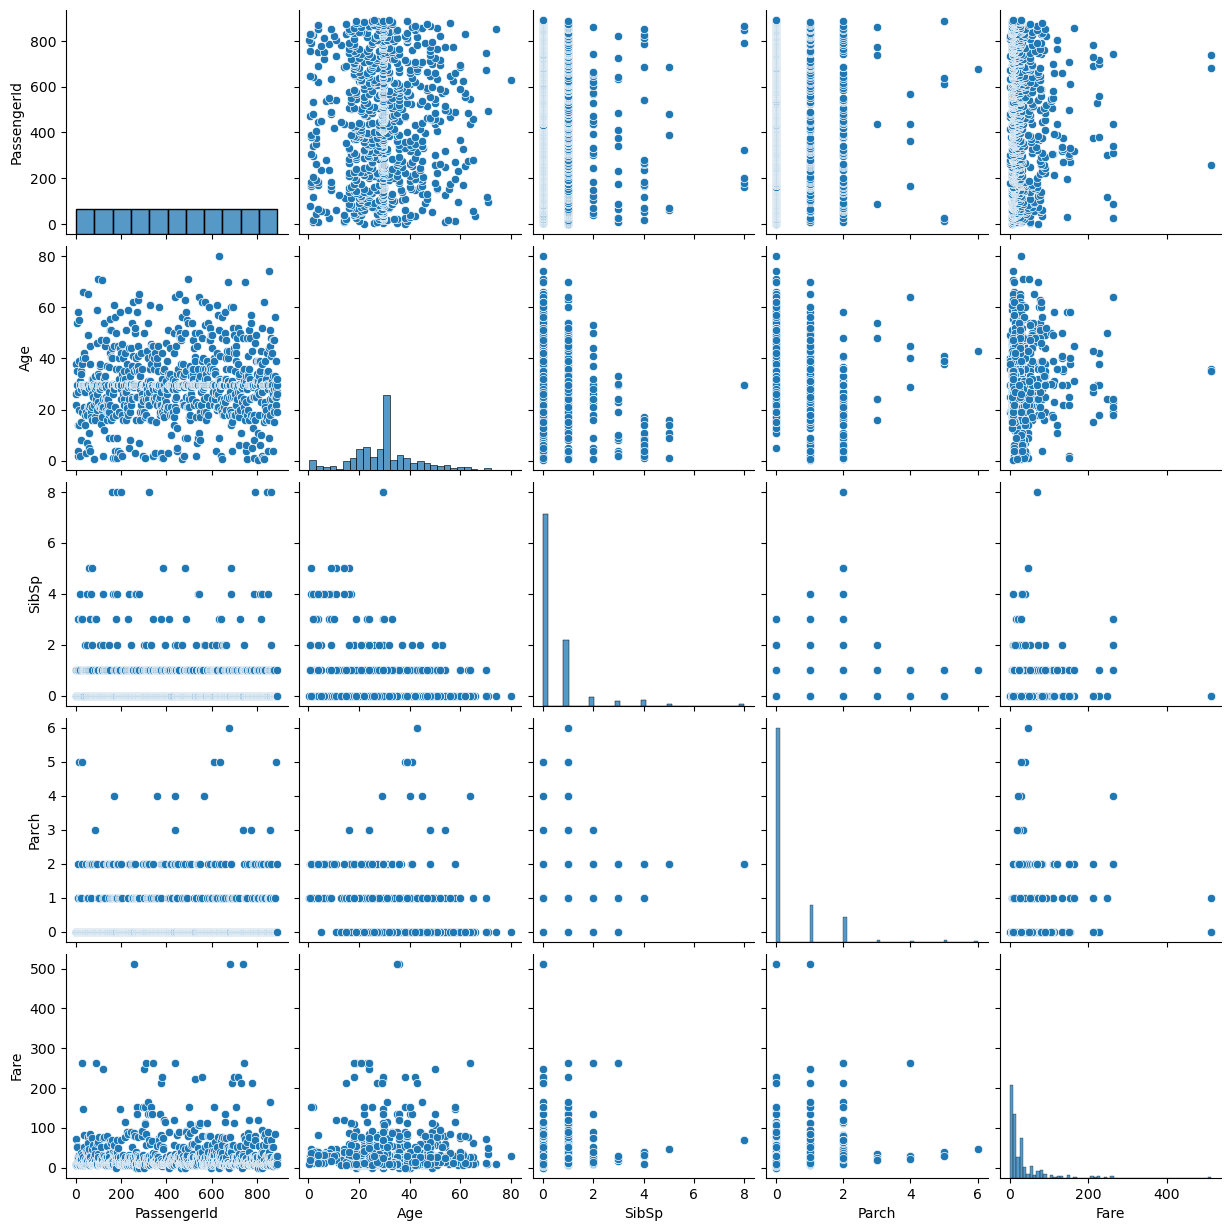

In [108]:
sns.pairplot(df)

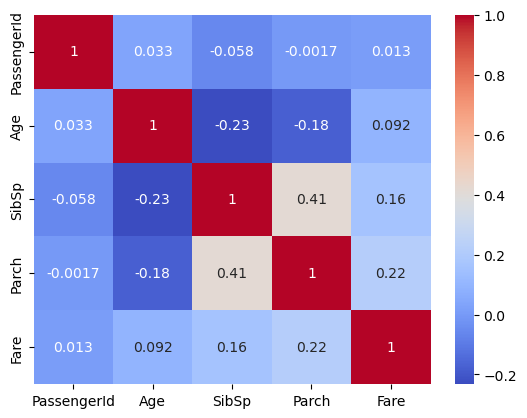

In [109]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [110]:
df['family_size'] = df['Parch'] + df['SibSp']

In [111]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size
137,138,0,1,"Futrelle, Mr. Jacques Heath",male,37.000000,1,0,113803,53.1000,S,1
560,561,0,3,"Morrow, Mr. Thomas Rowan",male,29.699118,0,0,372622,7.7500,Q,0
480,481,0,3,"Goodwin, Master. Harold Victor",male,9.000000,5,2,CA 2144,46.9000,S,7
141,142,1,3,"Nysten, Miss. Anna Sofia",female,22.000000,0,0,347081,7.7500,S,0
621,622,1,1,"Kimball, Mr. Edwin Nelson Jr",male,42.000000,1,0,11753,52.5542,S,1


In [119]:
df.drop(columns=['SibSp', 'Parch', 'family_size'], inplace=True, errors='ignore')

In [125]:
df['family_size'] = df['SibSp'] + df['Parch'] + 1

def family_type(size):
    if size == 1:
        return 'Alone'
    elif size <= 4:
        return 'Small'
    else:
        return 'Large'

df['family_type'] = df['family_size'].apply(family_type)

KeyError: 'SibSp'

In [116]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked
814,815,0,3,"Tomlin, Mr. Ernest Portage",male,30.5,364499,8.050,S
380,381,1,1,"Bidois, Miss. Rosalie",female,42.0,PC 17757,227.525,C
675,676,0,3,"Edvardsson, Mr. Gustaf Hjalmar",male,18.0,349912,7.775,S
398,399,0,2,"Pain, Dr. Alfred",male,23.0,244278,10.500,S
383,384,1,1,"Holverson, Mrs. Alexander Oskar (Mary Aline To...",female,35.0,113789,52.000,S


In [117]:
pd.crosstab(df['family_type'], df['Survived']).apply(lambda r: round((r / r.sum()) * 100, 1),axis=1)

KeyError: 'family_type'

In [63]:
df = df[df['Age'] < (df['Age'].mean() + 3 * df['Age'].std())]
df.shape

(712, 14)

In [65]:
Q1 = np.percentile(df['Fare'], 25)
Q3 = np.percentile(df['Fare'], 75)

IQR = Q3 - Q1

outlier_low = Q1 - 1.5 * IQR
outlier_high = Q3 + 1.5 * IQR

df = df[(df['Fare'] >= outlier_low) & (df['Fare'] <= outlier_high)]

In [66]:
df.sample(4)
pd.get_dummies (data=df, columns=['Pclass', 'Sex', 'Embarked', 'family_type'], drop_first=True)

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,family_size,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,family_type_Large,family_type_Small
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,2,False,True,True,False,True,False,True
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,2,False,False,False,False,False,False,True
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,1,False,True,False,False,True,False,False
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,2,False,False,False,False,True,False,True
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,1,False,True,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,"Rice, Mrs. William (Margaret Norton)",39.0,0,5,382652,29.1250,NaN,6,False,True,False,True,False,True,False
886,887,0,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,1,True,False,True,False,True,False,False
887,888,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,1,False,False,False,False,True,False,False
889,890,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,1,False,False,True,False,False,False,False


In [67]:
df=pd.get_dummies(data=df, columns=['Pclass', 'Sex', 'Embarked', 'family_type'], drop_first=True)

<Axes: >

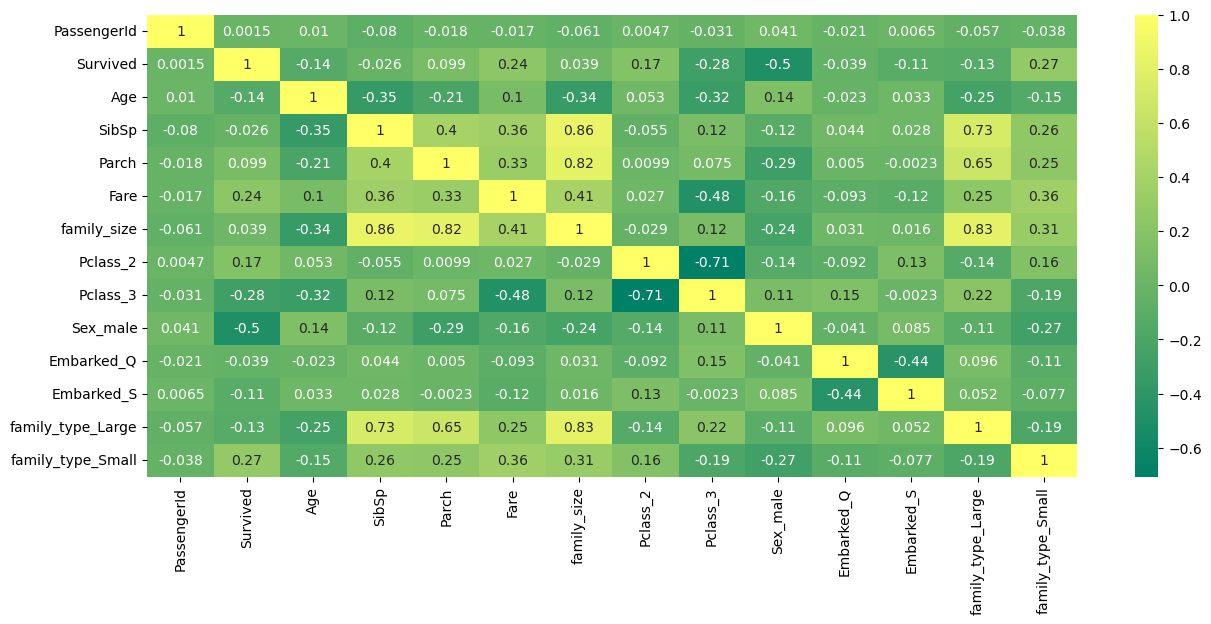

In [69]:
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='summer')